#  Flight Delay Prediction
## Phase 3 — Exploratory Data Analysis (EDA)

---

| Field | Details |
|---|---|
| **Course** | COMP4381 – Data Science and Analytics, Spring 2026 |
| **Instructor** | Ahmed Sabbah |



---

## 1. Introduction

Flight delays are one of the most serious challenges facing the aviation industry, as they negatively impact the passenger experience and cause financial losses for airlines and airports. This project aims to analyse and predict delay patterns by establishing an integrated data science pipeline.

The dataset used consists of approximately 1.7 million flight records covering nine major airports in the United States during 2024, including information on departure and arrival times, reasons for delays, airlines, and distances.

This report covers the third phase of the project, which is organised as follows: data description, data cleaning and missing value handling, exploratory analysis, and visualisation.

---
## 2. Dataset Source

| Property | Value |
|---|---|
| **Source** | Kaggle – Flight Delay Dataset |
| **Total Records** | 1,747,627 flights |
| **Total Features** | 16 columns |
| **Airports Covered** | ATL, DFW, JFK, LAX, ORD, BOS, MIA, SEA, SFO |
| **File Path** | `https://drive.google.com/file/d/1wWvYntzU-XzEKTwzAM891U3jTdzmyy-s/view?usp=drive_link` |

The flight data set includes scheduled and actual departure and arrival times, airline codes, departure and arrival airports, and the duration of delays in minutes.


---
## 3. Import Libraries

We use the standard Python libraries, including:

- **`pandas`** — data loading, cleaning and manipulation
- **`numpy`** — numerical operations and array handling
- **`matplotlib` / `seaborn`** — visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print('[OK] Libraries imported successfully!')

[OK] Libraries imported successfully!


---
## 4. Load Dataset

The dataset was saved on Google Drive (https://drive.google.com/file/d/1wWvYntzU-XzEKTwzAM891U3jTdzmyy-s/view?usp=drive_link) and loaded in the notebook using its shared file ID. We used `gdown` to download the file as `flight_delays.csv`, then used `pandas.read_csv()` to load it into a DataFrame. This makes the notebook easier to run without manual downloads or path changes.

In [2]:
import os
try:
    import gdown
except ModuleNotFoundError:
    !pip install -q gdown
    import gdown

file_id = "1wWvYntzU-XzEKTwzAM891U3jTdzmyy-s"
url = f"https://drive.google.com/uc?id={file_id}"
output_path = "flight_delays.csv"

if not os.path.exists(output_path):
    gdown.download(url, output_path, quiet=True)

df = pd.read_csv(output_path)

print(f"[OK] Data loaded successfully: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

[OK] Data loaded successfully: 1,747,627 rows, 16 columns


---
## 5. Dataset Structure

We examine the first few rows to understand the data structure before applying any transformations. This enables us to identify obvious formatting issues or unexpected values at an early stage.



In [3]:
print('=' * 70)
print('DATASET STRUCTURE — FIRST 5 ROWS')
print('=' * 70)
df.head()

DATASET STRUCTURE — FIRST 5 ROWS


,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298


---
## 6. Dataset Dimensions

We confirm the total number of rows and columns to verify the data loaded completely.

In [4]:
print('=' * 70)
print('DATASET DIMENSIONS')
print('=' * 70)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]:,}')

DATASET DIMENSIONS
  Rows    : 1,747,627
  Columns : 16


---
## 7. Column Names & Types

It is necessary to understand the data type of each column before taking any steps to clean the data. Inconsistencies in data types (such as a numeric column stored as an ‘object’) are a common source of errors.


In [5]:
print('=' * 70)
print('COLUMN NAMES')
print('=' * 70)
for idx, col in enumerate(df.columns, 1):
    print(f'  {idx:2d}. {col}')

COLUMN NAMES
   1. FlightID
   2. Airline
   3. FlightNumber
   4. Origin
   5. Destination
   6. ScheduledDeparture
   7. ActualDeparture
   8. ScheduledArrival
   9. ActualArrival
  10. DelayMinutes
  11. DelayReason
  12. Cancelled
  13. Diverted
  14. AircraftType
  15. TailNumber
  16. Distance


In [6]:
print('=' * 70)
print('DATA TYPE DISTRIBUTION')
print('=' * 70)
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {str(dtype):20s}: {count} column(s)')

DATA TYPE DISTRIBUTION
  str                 : 10 column(s)
  int64               : 4 column(s)
  bool                : 2 column(s)


In [7]:
print('=' * 70)
print('COLUMN SUMMARY TABLE')
print('=' * 70)
desc = pd.DataFrame({
    'Column'  : df.columns,
    'Type'    : df.dtypes.values,
    'Missing' : df.isnull().sum().values
})
print(desc.to_string(index=False))

COLUMN SUMMARY TABLE
            Column  Type  Missing
          FlightID int64        0
           Airline   str        0
      FlightNumber int64        0
            Origin   str        0
       Destination   str        0
ScheduledDeparture   str        0
   ActualDeparture   str        0
  ScheduledArrival   str        0
     ActualArrival   str        0
      DelayMinutes int64        0
       DelayReason   str   468873
         Cancelled  bool        0
          Diverted  bool        0
      AircraftType   str        0
        TailNumber   str        0
          Distance int64        0


---
## 8. Missing Values Analysis

Incomplete data may lead to a skewed model or cause it to fail. In this case, we calculate the total data completeness rate as a percentage and indicate which columns require missing data to be completed or deleted.

A data completeness rate exceeding 95% is generally considered acceptable for tabular datasets.

In [8]:
completeness = (1 - (df.isnull().sum().sum() / (len(df) * len(df.columns)))) * 100
print(f'  Data Completeness : {completeness:.2f}%')

missing_per_col = df.isnull().sum()
missing_cols = missing_per_col[missing_per_col > 0]
if missing_cols.empty:
    print('  [OK] No missing values detected in any column.')
else:
    print('\n  Columns with missing values:')
    print(missing_cols.to_string())

  Data Completeness : 98.32%

  Columns with missing values:
DelayReason    468873


---
## 9. Duplicate Records

Duplicate rows may provide a distortion of the statistical and training summaries. We will inquire again to confirm the presence of duplicate questions and report the number.


In [9]:
dups = df.duplicated().sum()
print(f'  Duplicate rows : {dups:,}')
if dups == 0:
    print('  [OK] No duplicate records found — data is unique.')
else:
    print(f'  [!] {dups:,} duplicate rows detected. Consider removing them before modelling.')

  Duplicate rows : 0
  [OK] No duplicate records found — data is unique.


---
## 10. Descriptive Statistics

We calculate standard summary statistics (count, mean, standard deviation, minimum, quartiles, maximum) for all **numeric columns**. This helps determine the range and spread of delay values ​​and other continuous properties.

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

,FlightID,FlightNumber,DelayMinutes,Distance
count,1747627.00,1747627.00,1747627.00,1747627.00
mean,873814.00,5001.16,10.00,1549.94
std,504496.60,2885.82,11.83,836.87
min,1.00,1.00,-10.00,100.00
25%,436907.50,2503.00,0.00,825.00
50%,873814.00,5002.00,10.00,1551.00
75%,1310720.50,7499.00,20.00,2274.00
max,1747627.00,9999.00,30.00,3000.00


---
## 11. Delay Analysis

The key variable of interest is "delay duration in minutes." Here we will examine the following:

- **Average delay** for all flights
- **Number of delayed flights** (where "delay duration in minutes" > 0)
- **Percentage of delayed flights** to the total number of flights

This provides an initial picture of the frequency and severity of delays.

In [11]:
delay_stats = df['DelayMinutes'].describe()
delayed     = (df['DelayMinutes'] > 0).sum()
delay_pct   = (delayed / len(df)) * 100

print('=' * 70)
print('DELAY SUMMARY')
print('=' * 70)
print(f'  Mean Delay       : {delay_stats["mean"]:.2f} minutes')
print(f'  Median Delay     : {delay_stats["50%"]:.2f} minutes')
print(f'  Max Delay        : {delay_stats["max"]:.2f} minutes')
print(f'  Delayed Flights  : {delayed:,}  ({delay_pct:.2f}% of total)')

DELAY SUMMARY
  Mean Delay       : 10.00 minutes
  Median Delay     : 10.00 minutes
  Max Delay        : 30.00 minutes
  Delayed Flights  : 1,278,754  (73.17% of total)


---

## 12. Detecting outliers

We use the **interquartile range (IQR)** to detect outliers in `DelayMinutes`. A value is classified as an outlier if it is less than `Q1 − 1.5×IQR` or greater than `Q3 + 1.5×IQR`.

Outlier delay values may result from genuine disruptions (such as severe weather conditions or mechanical failures) or data entry errors 

In [12]:
Q1  = df['DelayMinutes'].quantile(0.25)
Q3  = df['DelayMinutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df['DelayMinutes'] < lower_bound) | (df['DelayMinutes'] > upper_bound)).sum()

print('=' * 70)
print('OUTLIER DETECTION — DelayMinutes (IQR Method)')
print('=' * 70)
print(f'  Q1 (25th pct)    : {Q1:.2f} min')
print(f'  Q3 (75th pct)    : {Q3:.2f} min')
print(f'  IQR              : {IQR:.2f} min')
print(f'  Lower Bound      : {lower_bound:.2f} min')
print(f'  Upper Bound      : {upper_bound:.2f} min')
print(f'  Outliers Found   : {outliers:,}')

OUTLIER DETECTION — DelayMinutes (IQR Method)
  Q1 (25th pct)    : 0.00 min
  Q3 (75th pct)    : 20.00 min
  IQR              : 20.00 min
  Lower Bound      : -30.00 min
  Upper Bound      : 50.00 min
  Outliers Found   : 0


---
## 13. Airport Analysis

All historical airports that were either **level airports** or **destination airports** were identified in the dataset.

In [13]:
origins      = df['Origin'].unique()
destinations = df['Destination'].unique()
all_airports = sorted(set(list(origins) + list(destinations)))

print('=' * 70)
print('AIRPORT COVERAGE')
print('=' * 70)
print(f'  Origin airports      : {len(origins)}')
print(f'  Destination airports : {len(destinations)}')
print(f'  Total unique airports: {len(all_airports)}')
print(f'  Airport codes        : {", ".join(all_airports)}')

AIRPORT COVERAGE
  Origin airports      : 5
  Destination airports : 5
  Total unique airports: 9
  Airport codes        : ATL, BOS, DFW, JFK, LAX, MIA, ORD, SEA, SFO


---
## 14. Airline Distribution

We examine how flights are distributed among airlines. A highly unbalanced distribution (the dominance of one airline) can lead to bias in the model, so this step is useful in any subsequent decisions regarding stratified sampling.

In [14]:
airline_counts = df['Airline'].value_counts()

print('=' * 70)
print('AIRLINE DISTRIBUTION')
print('=' * 70)
for airline, count in airline_counts.items():
    pct = (count / len(df)) * 100
    bar = '' * int(pct / 2)
    print(f'  {airline:6s} : {count:>9,}  ({pct:5.2f}%)  {bar}')

AIRLINE DISTRIBUTION
  Southwest :   437,721  (25.05%)  
  American Airlines :   437,124  (25.01%)  
  Delta  :   436,680  (24.99%)  
  United :   436,102  (24.95%)  


# **15. Data Cleaning** 
 This section focuses on improving the quality of the dataset by identifying and removing duplicate records. Duplicate entries may lead to inaccurate analytical results and affect future machine learning models.   



In [15]:
print("="*70)
print("DATA CLEANING")
print("="*70)

df_clean = df.copy()

print(f"Original Dataset Shape: {df_clean.shape}")

duplicates = df_clean.duplicated().sum()

print(f"\nNumber of Duplicate Records: {duplicates}")

df_clean = df_clean.drop_duplicates()

print(f"Dataset Shape After Removing Duplicates: {df_clean.shape}")

DATA CLEANING
Original Dataset Shape: (1747627, 16)

Number of Duplicate Records: 0
Dataset Shape After Removing Duplicates: (1747627, 16)


# **16. Missing Values Analysis**

Missing values can negatively affect statistical analysis and predictive modeling. This step identifies missing values across all dataset attributes.

In [16]:
print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_values = df_clean.isnull().sum()

print("Missing Values Per Column:")
print(missing_values[missing_values > 0])

MISSING VALUES ANALYSIS
Missing Values Per Column:
DelayReason    468873
dtype: int64


The output shows the number of missing values in each feature. Features that contain missing values must be handled appropriately before further processing.

# **17. Missing Values Treatment**
Handle missing values to help improve data completeness and maintain the quality of the dataset.

In [17]:
before_missing = df_clean["DelayReason"].isnull().sum()

df_clean["DelayReason"] = df_clean["DelayReason"].fillna("No Delay/Unknown")

after_missing = df_clean["DelayReason"].isnull().sum()

print(f"Missing values in DelayReason before treatment: {before_missing}")
print(f"Missing values in DelayReason after treatment: {after_missing}")

Missing values in DelayReason before treatment: 468873
Missing values in DelayReason after treatment: 0


Most missing values were in the DelayReason column. We did not remove these rows because they still contain useful flight information. Instead, we replaced the missing values with “No Delay/Unknown” so the dataset stays complete and ready for analysis.

# **18. Data Quality Verification**
    
Verify that all duplicates and missing values have been successfully handled.

In [18]:
print("="*70)
print("DATA QUALITY VERIFICATION")
print("="*70)

print("Remaining Missing Values:")
print(df_clean.isnull().sum().sum())

print("\nRemaining Duplicate Records:")
print(df_clean.duplicated().sum())

DATA QUALITY VERIFICATION
Remaining Missing Values:
0

Remaining Duplicate Records:
0


The dataset was validated following data cleaning to confirm that there are no duplicate records or missing values.

# **19. Data Preprocessing**

Prepare the dataset for feature engineering by standardizing column names and converting date/time columns into appropriate formats.

In [19]:
print("="*70)
print("DATA PREPROCESSING")
print("="*70)

df_clean.columns = df_clean.columns.str.strip()

date_columns = [
    "ScheduledDeparture",
    "ActualDeparture",
    "ScheduledArrival",
    "ActualArrival"
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col])

print("Date and Time Conversion Completed Successfully")

DATA PREPROCESSING
Date and Time Conversion Completed Successfully


In [20]:
df_clean["Route"] = df_clean["Origin"] + "-" + df_clean["Destination"]

df_clean["ScheduledHour"] = df_clean["ScheduledDeparture"].dt.hour
df_clean["ArrivalHour"] = df_clean["ScheduledArrival"].dt.hour
df_clean["Weekday"] = df_clean["ScheduledDeparture"].dt.day_name()
df_clean["Month"] = df_clean["ScheduledDeparture"].dt.month

df_clean[["Route", "ScheduledHour", "ArrivalHour", "Weekday", "Month"]].head()

,Route,ScheduledHour,ArrivalHour,Weekday,Month
0,ORD-MIA,8,12,Sunday,9
1,LAX-MIA,10,13,Sunday,9
2,DFW-SFO,16,17,Sunday,9
3,ORD-BOS,14,18,Sunday,9
4,LAX-SEA,1,5,Sunday,9


The date and time columns were converted into datetime format, allowing time-based calculations and feature extraction.

# **20. Feature Engineering: Departure Delay**

Calculate the difference between actual and scheduled departure times.

In [21]:
df_clean["DepartureDelay"] = (
    df_clean["ActualDeparture"] -
    df_clean["ScheduledDeparture"]
).dt.total_seconds() / 60

df_clean["DepartureDelay"].describe()

count   1747627.00
mean         15.00
std           8.95
min           0.00
25%           7.00
50%          15.00
75%          23.00
max          30.00
Name: DepartureDelay, dtype: float64

The Departure Delay Index measures the number of minutes a flight departs before or after its scheduled time.

It contains a dataset of 1,747,627 flights with documented departure delays.

The average departure delay is 15 minutes, indicating that flights generally depart 15 minutes late.

Standard Deviation 8.95:

This metric indicates the variability of departure delays around the average. A standard deviation of 8.95 minutes indicates average variability in departure performance among flights.

Minimum 0.00:

The lowest departure delay is zero minutes, meaning some flights departed exactly on time.

25% (Q1 - 7.00):

This quarter shows that 25% of flights were delayed by 7 minutes or less.   
The mean take-off delay is 15 minutes, meaning that half of the flights depart within 15 minutes of their scheduled departure time, and the other half experience longer delays.



75% (Third quartile – 23.00):

This value means that 75% took off 23 minutes or less late, while only 25% were more than 23 minutes late.



Maximum 30.00:

The maximum recorded take-off delay is 30 minutes, which is the longest delay in the data.


# **21. Feature Engineering: Arrival Delay**

Calculate the difference between actual and scheduled arrival times.

In [22]:
df_clean["ArrivalDelay"] = (
    df_clean["ActualArrival"] -
    df_clean["ScheduledArrival"]
).dt.total_seconds() / 60

df_clean["ArrivalDelay"].describe()

count   1747627.00
mean         10.00
std          11.83
min         -10.00
25%           0.00
50%          10.00
75%          20.00
max          30.00
Name: ArrivalDelay, dtype: float64

ArrivalDelay measures the  time difference between actual and planned arrival times and provides a useful indicator of operational performance.

# **22. Feature Engineering: Flight Duration**

Calculate the actual flight duration in minutes.

In [23]:
df_clean["FlightDuration"] = (
    df_clean["ActualArrival"] -
    df_clean["ActualDeparture"]
).dt.total_seconds() / 60

df_clean["FlightDuration"].describe()

count   1747627.00
mean        205.01
std         103.53
min          20.00
25%         115.00
50%         205.00
75%         295.00
max         390.00
Name: FlightDuration, dtype: float64

FlightDuration represents the actual travel time of each flight and may help explain delay patterns.

# **23. Creating Distance Category**

Group flights into distance categories for easier analysis.

In [24]:
def distance_category(distance):
    if distance < 500:
        return "Short"
    elif distance < 1000:
        return "Medium"
    else:
        return "Long"

df_clean["DistanceCategory"] = df_clean["Distance"].apply(distance_category)

df_clean["DistanceCategory"].value_counts()

DistanceCategory
Long      1206064
Medium     300904
Short      240659
Name: count, dtype: int64

Flights were categorised into Short, Medium and Long routes based on distance travelled.

# **24. Creating Delay Category**

Classify flights into delay categories based on the number of delay minutes.

In [25]:
def categorize_delay(delay):
    if delay <= 0:
        return "Early/On Time"
    elif delay <= 15:
        return "Small Delay"
    elif delay <= 30:
        return "Moderate Delay"
    else:
        return "Large Delay"

df_clean["DelayCategory"] = df_clean["DelayMinutes"].apply(categorize_delay)

df_clean["DelayCategory"].value_counts()

DelayCategory
Small Delay       639437
Moderate Delay    639317
Early/On Time     468873
Name: count, dtype: int64

In [26]:
df_clean["IsDelayed"] = df_clean["DelayMinutes"].apply(lambda x: 1 if x > 15 else 0)

df_clean["IsDelayed"].value_counts()

IsDelayed
0    1108310
1     639317
Name: count, dtype: int64

Flights were grouped into Early/On Time, Minor Delay and Moderate Delay categories to make it easier to analyse delay patterns.

# **25. Validating the Final Dataset**

Review the structure of the final dataset after it has been cleaned and pre-processed.

In [27]:
print("="*70)
print("FINAL DATASET VALIDATION")
print("="*70)

print("Dataset Shape:")
print(df_clean.shape)

print("\nDataset Information:")
df_clean.info()

FINAL DATASET VALIDATION
Dataset Shape:
(1747627, 27)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 27 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             str           
 2   FlightNumber        int64         
 3   Origin              str           
 4   Destination         str           
 5   ScheduledDeparture  datetime64[us]
 6   ActualDeparture     datetime64[us]
 7   ScheduledArrival    datetime64[us]
 8   ActualArrival       datetime64[us]
 9   DelayMinutes        int64         
 10  DelayReason         str           
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        str           
 14  TailNumber          str           
 15  Distance            int64         
 16  Route               str           
 17  ScheduledHour       int32         
 18  ArrivalHour      

The structure of the final dataset was reviewed to ensure that all transformations were successfully applied.


# **26. Dataset Preview**

Display a sample of the final processed dataset.

In [28]:
df_clean.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance,Route,ScheduledHour,ArrivalHour,Weekday,Month,DepartureDelay,ArrivalDelay,FlightDuration,DistanceCategory,DelayCategory,IsDelayed
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031,ORD-MIA,8,12,Sunday,9,19.00,8.00,229.00,Long,Small Delay,0
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006,LAX-MIA,10,13,Sunday,9,16.00,2.00,166.00,Long,Small Delay,0
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980,DFW-SFO,16,17,Sunday,9,12.00,14.00,62.00,Long,Small Delay,0
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay/Unknown,False,False,Boeing 777,N90029,1408,ORD-BOS,14,18,Sunday,9,20.00,-10.00,210.00,Long,Early/On Time,0
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298,LAX-SEA,1,5,Sunday,9,17.00,24.00,247.00,Long,Moderate Delay,1


The preview gives a quick overview of the cleaned and transformed dataset.

# **27. Saving the Processed Dataset**



In [29]:
import os

os.makedirs("../data/processed", exist_ok=True)

output_file = "../data/processed/flight_delays_cleaned.csv"

df_clean.to_csv(output_file, index=False)

print("Dataset Saved Successfully")
print(output_file)

Dataset Saved Successfully
../data/processed/flight_delays_cleaned.csv


The processed dataset was successfully saved.

---
## 28. Summary Statistics

We summarizes the main numerical features in the cleaned dataset. The summary statistics help us understand the typical delay time, flight distance, flight duration, and time-related features before creating visualizations.

In [30]:
numeric_columns = [
    "DelayMinutes",
    "Distance",
    "FlightDuration",
    "ScheduledHour",
    "ArrivalHour",
    "IsDelayed"
]

summary_stats = df_clean[numeric_columns].describe()

summary_stats

,DelayMinutes,Distance,FlightDuration,ScheduledHour,ArrivalHour,IsDelayed
count,1747627.00,1747627.00,1747627.00,1747627.00,1747627.00,1747627.00
mean,10.00,1549.94,205.01,11.51,11.50,0.37
std,11.83,836.87,103.53,6.92,6.92,0.48
min,-10.00,100.00,20.00,0.00,0.00,0.00
25%,0.00,825.00,115.00,6.00,5.00,0.00
50%,10.00,1551.00,205.00,12.00,12.00,0.00
75%,20.00,2274.00,295.00,18.00,17.00,1.00
max,30.00,3000.00,390.00,23.00,23.00,1.00


The dataset has 1,747,627 flights. The average delay is 10 minutes, and the median is also 10 minutes, so most delay values are centered around this number. DelayMinutes ranges from -10 to 30 minutes, meaning some flights were early while others had small or moderate delays.

The average distance is about 1549.94, and the average flight duration is about 205 minutes. Also, the mean of IsDelayed is 0.37, which means around 37% of flights are classified as delayed.

In [31]:
mean_delay = df_clean["DelayMinutes"].mean()
median_delay = df_clean["DelayMinutes"].median()
std_delay = df_clean["DelayMinutes"].std()
min_delay = df_clean["DelayMinutes"].min()
max_delay = df_clean["DelayMinutes"].max()

print(f"Mean Delay: {mean_delay:.2f} minutes")
print(f"Median Delay: {median_delay:.2f} minutes")
print(f"Standard Deviation: {std_delay:.2f} minutes")
print(f"Minimum Delay: {min_delay:.2f} minutes")
print(f"Maximum Delay: {max_delay:.2f} minutes")

Mean Delay: 10.00 minutes
Median Delay: 10.00 minutes
Standard Deviation: 11.83 minutes
Minimum Delay: -10.00 minutes
Maximum Delay: 30.00 minutes


This dataset shows that the mean and median delay are both 10 minutes. This suggests that delays are generally moderate and not extreme. The minimum delay is -10 minutes and the maximum is 30 minutes, so this dataset does not include cases of very long delays.

---
## 29. Categorical Summary

We summarized the main categorical columns in the cleaned dataset, such as airlines, delay reasons, delay categories, and distance categories. These summaries help us understand how flights are distributed across different groups.

In [32]:
df_clean["Airline"].value_counts()

Airline
Southwest            437721
American Airlines    437124
Delta                436680
United               436102
Name: count, dtype: int64

The airline distribution is almost balanced. Southwest has the highest number of records with 437,721 flights, followed by American Airlines with 437,124, Delta with 436,680, and United with 436,102. The numbers are very close, so comparing airlines later will be fair because no airline strongly dominates the dataset.

In [33]:
df_clean["DelayReason"].value_counts()

DelayReason
No Delay/Unknown       468873
Air Traffic Control    426488
Maintenance            426168
Weather                426098
Name: count, dtype: int64

The DelayReason column shows that 468,873 flights have "No Delay/Unknown", which means no clear delay reason was recorded. The recorded delay reasons are also very close in count: Air Traffic Control has 426,488 records, Maintenance has 426,168, and Weather has 426,098. This means the delay reasons are nearly balanced in the dataset.

In [34]:
df_clean["DelayCategory"].value_counts()

DelayCategory
Small Delay       639437
Moderate Delay    639317
Early/On Time     468873
Name: count, dtype: int64

The DelayCategory output shows that most flights fall into Small Delay and Moderate Delay. Small Delay has 639,437 flights, while Moderate Delay has 639,317 flights. Early/On Time flights are fewer, with 468,873 records. This shows that the dataset contains many delayed flights, but the delays are mostly small or moderate.

In [35]:
df_clean["DistanceCategory"].value_counts()

DistanceCategory
Long      1206064
Medium     300904
Short      240659
Name: count, dtype: int64

The DistanceCategory output shows that most flights are Long flights, with 1,206,064 records. Medium flights have 300,904 records, and Short flights have 240,659 records. This means the dataset is dominated by long-distance flights, so distance-related results should be interpreted with this imbalance in mind.

---
## 30. Visualizations

We used visualizations for better understanding of the patterns in the cleaned dataset. The charts focus on delay minutes, delay categories, airlines, delay reasons, distance categories, and the relationship between distance and delay.

30.1 Distribution of Delay Minutes:

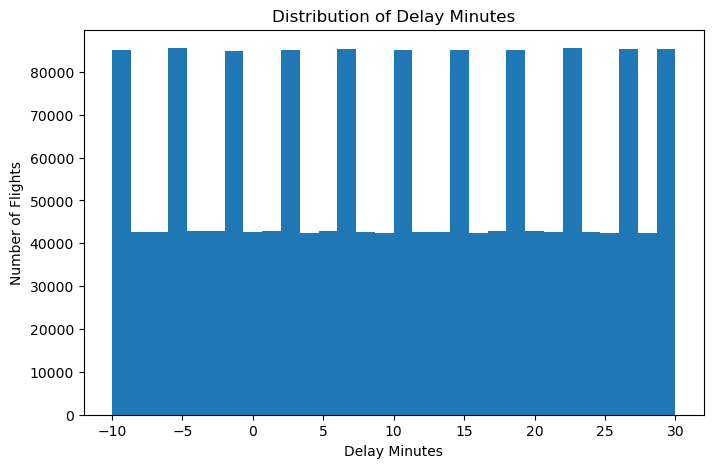

In [36]:
import os

figures_path = "../figures"
os.makedirs(figures_path, exist_ok=True)
plt.figure(figsize=(8, 5))
plt.hist(df_clean["DelayMinutes"], bins=30)
plt.title("Distribution of Delay Minutes")
plt.xlabel("Delay Minutes")
plt.ylabel("Number of Flights")

plt.savefig("../figures/distribution_delay_minutes.png", bbox_inches="tight")

plt.show()

The chart shows that delay values are between -10 and 30 minutes. Some delay values, such as -10 minutes, appear more than 80,000 times, which means many flights arrived or departed early. Other delay values are also spread across the range, showing that the dataset includes early flights, small delays, and moderate delays. There are no extreme delay cases in this dataset.

30.2 Distribution of Delay Categories

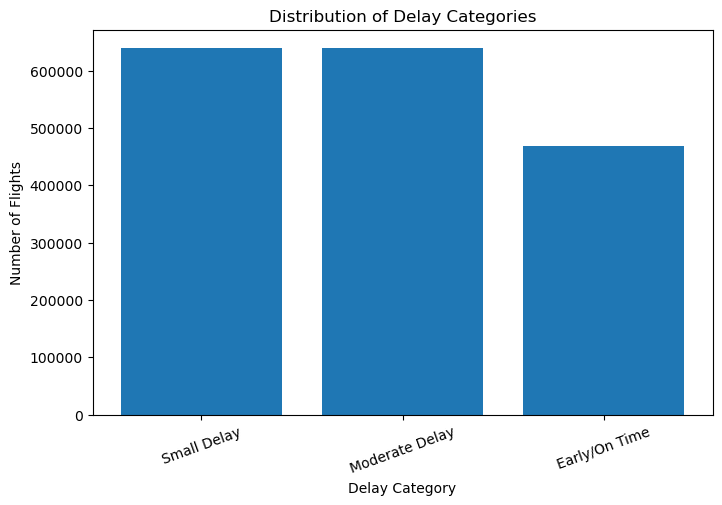

In [37]:
delay_category_counts = df_clean["DelayCategory"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(delay_category_counts.index, delay_category_counts.values)
plt.title("Distribution of Delay Categories")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")
plt.xticks(rotation=20)

plt.savefig("../figures/distribution_delay_categories.png", bbox_inches="tight")

plt.show()

This chart shows that Small Delay and Moderate Delay are the most common categories, and both have almost the same number of flights, around 650,000 each. Early/On Time flights are lower, with about 470,000 flights. This means most flights in the dataset had some delay, but the delay was usually small or moderate, not extreme.

30.3 Average Delay by Airline

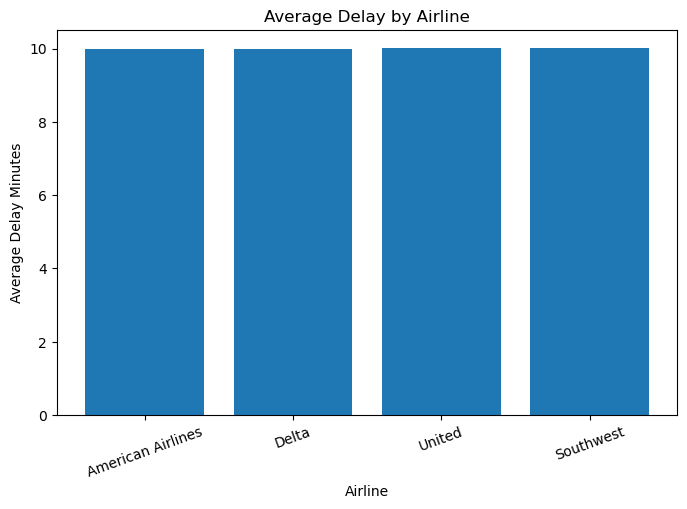

In [38]:
airline_delay = df_clean.groupby("Airline")["DelayMinutes"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(airline_delay.index, airline_delay.values)
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay Minutes")
plt.xticks(rotation=20)

plt.savefig("../figures/average_delay_by_airline.png", bbox_inches="tight")

plt.show()

This chart shows that the average delay is almost the same for all airlines, around 10 minutes. American Airlines, Delta, United, and Southwest have very close average delay values. This means that, in this dataset, no airline clearly has much higher or lower delay than the others.

30.4 Distribution of Delay Reasons

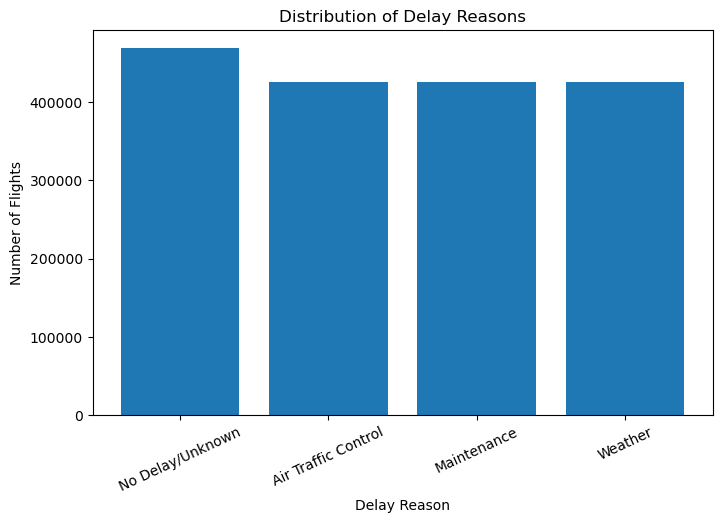

In [39]:
delay_reason_counts = df_clean["DelayReason"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(delay_reason_counts.index, delay_reason_counts.values)
plt.title("Distribution of Delay Reasons")
plt.xlabel("Delay Reason")
plt.ylabel("Number of Flights")
plt.xticks(rotation=25)

plt.savefig("../figures/distribution_delay_reasons.png", bbox_inches="tight")

plt.show()

This chart shows that "No Delay/Unknown" has the highest number of flights, with about 470,000 records. The other delay reasons are very close to each other: Air Traffic Control, Maintenance, and Weather each have around 420,000 flights. This means the recorded delay reasons are almost balanced in the dataset, while the unknown/no-delay category is slightly higher.

30.5 Average Delay by Distance Category

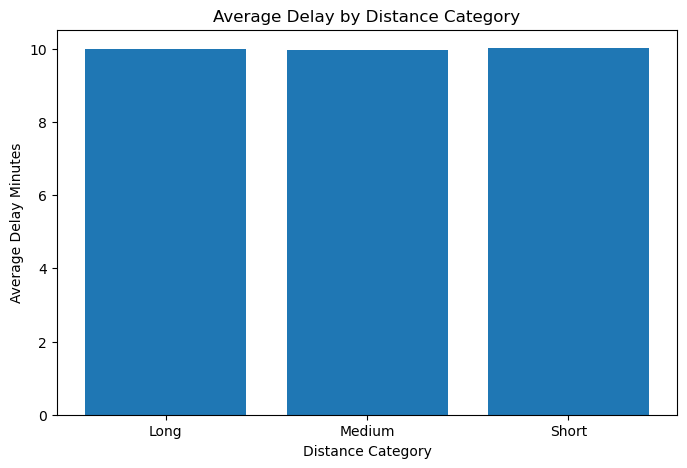

In [40]:
distance_delay = df_clean.groupby("DistanceCategory")["DelayMinutes"].mean()

plt.figure(figsize=(8, 5))
plt.bar(distance_delay.index, distance_delay.values)
plt.title("Average Delay by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Average Delay Minutes")

plt.savefig("../figures/average_delay_by_distance_category.png", bbox_inches="tight")

plt.show()

This chart shows that the average delay is almost the same for all distance categories. Long, medium, and short flights all have an average delay of about 10 minutes. This means that, in this dataset, flight distance does not seem to have a clear effect on the average delay.

30.6 Delay Distribution by Airline

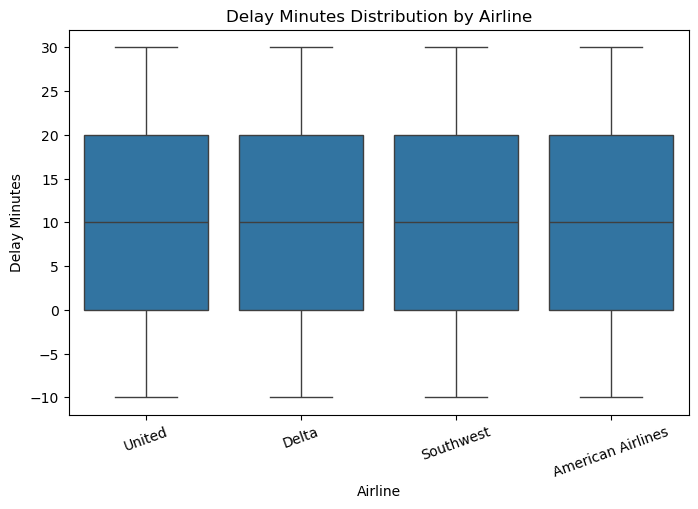

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="Airline", y="DelayMinutes")

plt.title("Delay Minutes Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Minutes")
plt.xticks(rotation=20)

plt.savefig("../figures/delay_distribution_by_airline.png", bbox_inches="tight")

plt.show()

This boxplot compares the distribution of delay minutes for each airline. The result shows that all airlines have almost the same delay range, from -10 to 30 minutes. The median delay for each airline is around 10 minutes, and the boxes look very similar. This means that delay behavior is almost the same across United, Delta, Southwest, and American Airlines in this dataset.

30.7 Distance vs Delay Minutes

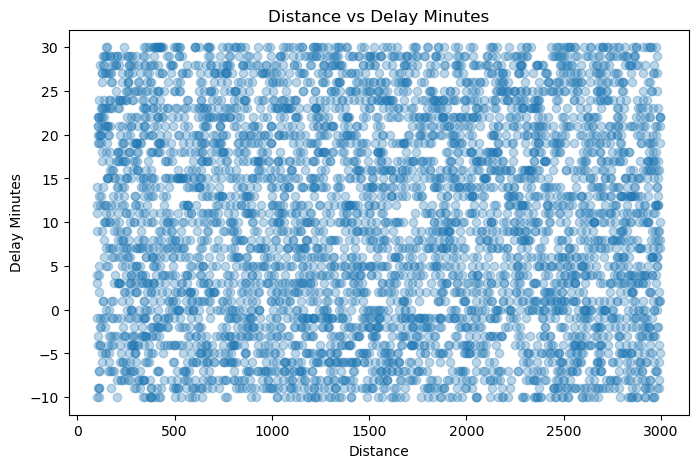

In [42]:
sample_df = df_clean.sample(5000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_df["Distance"], sample_df["DelayMinutes"], alpha=0.3)
plt.title("Distance vs Delay Minutes")
plt.xlabel("Distance")
plt.ylabel("Delay Minutes")

plt.savefig("../figures/distance_vs_delay_minutes.png", bbox_inches="tight")

plt.show()

This scatter plot compares distance with delay minutes using a sample of the dataset. The points are spread across all distances from about 100 to 3000, and delay values still range between -10 and 30 minutes. There is no clear upward or downward pattern, so distance alone does not seem to strongly explain flight delays in this dataset.

30.8 Flight Duration vs Delay Minutes.

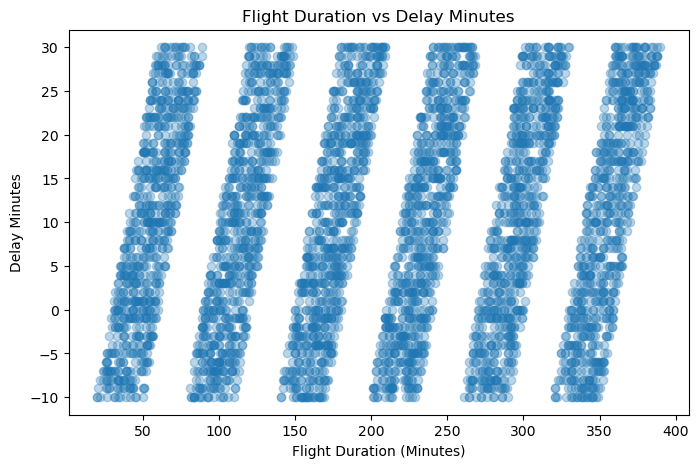

In [43]:
sample_df = df_clean.sample(5000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_df["FlightDuration"], sample_df["DelayMinutes"], alpha=0.3)
plt.title("Flight Duration vs Delay Minutes")
plt.xlabel("Flight Duration (Minutes)")
plt.ylabel("Delay Minutes")

plt.savefig("../figures/flight_duration_vs_delay_minutes.png", bbox_inches="tight")

plt.show()

This scatter plot shows flight duration compared with delay minutes. The points appear in separate groups because the dataset has repeated flight duration ranges. Inside each group, delay values still range from -10 to 30 minutes. There is no clear overall upward or downward trend, so flight duration alone does not seem to strongly explain delays in this dataset.

---
# 31. Correlation Analysis

WE checked the relationship between the numerical features in the dataset. So correlation helps us understand whether variables such as distance, flight duration, scheduled hour, or arrival hour are related to flight delays.

In [44]:
correlation_columns = [
    "DelayMinutes",
    "Distance",
    "FlightDuration",
    "ScheduledHour",
    "ArrivalHour",
    "IsDelayed"
]

correlation_matrix = df_clean[correlation_columns].corr()

correlation_matrix

,DelayMinutes,Distance,FlightDuration,ScheduledHour,ArrivalHour,IsDelayed
DelayMinutes,1.00,0.00,0.11,-0.00,0.00,0.83
Distance,0.00,1.00,0.00,0.00,0.00,-0.00
FlightDuration,0.11,0.00,1.00,-0.00,-0.00,0.10
ScheduledHour,-0.00,0.00,-0.00,1.00,0.28,-0.00
ArrivalHour,0.00,0.00,-0.00,0.28,1.00,0.00
IsDelayed,0.83,-0.00,0.10,-0.00,0.00,1.00


The results show a strong positive correlation between the variable `IsDelayed` and the variable `DelayMinutes`, with a value of 0.83. This is to be expected, as `IsDelayed` is derived from the number of minutes of delay. The variable `FlightDuration` shows a weak positive correlation with `DelayMinutes`, with a value of 0.11, meaning that longer flights may experience slightly longer delays, although this relationship is weak. Meanwhile, the correlation coefficients between the variables `Distance`, `ScheduledHour`, `ArrivalHour`, and the variable `DelayMinutes` are close to 0, meaning they do not show  a strong direct relationship to flight delays in this dataset.

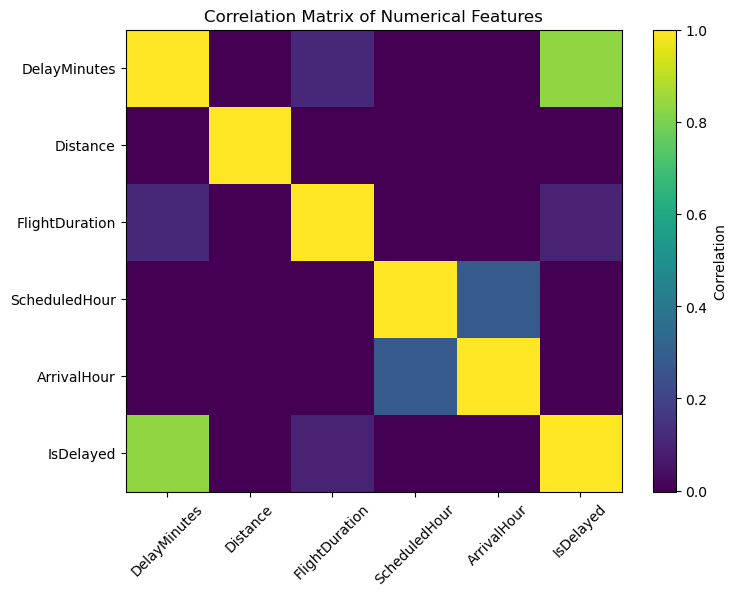

In [45]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45)
plt.yticks(range(len(correlation_columns)), correlation_columns)

plt.title("Correlation Matrix of Numerical Features")

plt.savefig("../figures/correlation_matrix.png", bbox_inches="tight")

plt.show()

The heatmap confirm the correlations table visually. The strongest relationship is between DelayMinutes and IsDelayed, which appears clearly with a high correlation around 0.83. There is also asmall relationship between ScheduledHour and ArrivalHour, around 0.28. Most other feature relationships are very weak and close to 0, especially Distance with DelayMinutes. This means distance, scheduled hour, and arrival hour don't strongly explain flight delays in this dataset.

---
# 32. Key Findings and Interpretation


In [46]:
print("Key Numerical Findings")
print("-" * 40)

print(f"Average delay: {df_clean['DelayMinutes'].mean():.2f} minutes")
print(f"Median delay: {df_clean['DelayMinutes'].median():.2f} minutes")
print(f"Minimum delay: {df_clean['DelayMinutes'].min():.2f} minutes")
print(f"Maximum delay: {df_clean['DelayMinutes'].max():.2f} minutes")
print(f"Delayed flights percentage: {df_clean['IsDelayed'].mean() * 100:.2f}%")

print("\nTop delay category:")
print(df_clean["DelayCategory"].value_counts().head(1))

print("\nMost common delay reason:")
print(df_clean["DelayReason"].value_counts().head(1))

print("\nStrongest correlations with DelayMinutes:")
print(correlation_matrix["DelayMinutes"].sort_values(ascending=False))

Key Numerical Findings
----------------------------------------
Average delay: 10.00 minutes
Median delay: 10.00 minutes
Minimum delay: -10.00 minutes
Maximum delay: 30.00 minutes
Delayed flights percentage: 36.58%

Top delay category:
DelayCategory
Small Delay    639437
Name: count, dtype: int64

Most common delay reason:
DelayReason
No Delay/Unknown    468873
Name: count, dtype: int64

Strongest correlations with DelayMinutes:
DelayMinutes      1.00
IsDelayed         0.83
FlightDuration    0.11
ArrivalHour       0.00
Distance          0.00
ScheduledHour    -0.00
Name: DelayMinutes, dtype: float64


The results show that the average delay is 10 minutes, and the median delay is also 10 minutes .This means that delays in the dataset are centered around 10 minutes. The delay values ​​are between -10 and 30 minutes, so the dataset includes early flights and moderate delays, but no cases of extreme delay.

Around 36.58% of flights are classified as delayed. The most common delay category is ‘SmallDelay’, with 639,437 flights. The most common reason for delay is ‘No Delay/Unknown’, with 468,873 records.

The correlation show that the strongest relationship with DelayMinutes is IsDelayed, with acorrelation of 0.83. This is to be expected, as IsDelayed was derived from DelayMinutes. FlightDuration has a weak positive correlation with DelayMinutes at 0.11, whilst Distance, ArrivalHour, and Scheduled Hour are close to 0. This means these numerical features do not strongly explain flight delays in this dataset.

